In [1]:
import time
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

import sys, os
sys.path.append(os.path.abspath("../src"))

from core import *
import viz as viz

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device ->", device)

cell_cfg = CellConfig(hidden_channels=8, visible_channels=1, alive_threshold=0.05)
perc_cfg = PerceptionConfig(kernel_radius=1, channel_groups=3)
upd_cfg = UpdateConfig(hidden_dim=64, stochastic_update=False, fire_rate=0.5)
grid_cfg = GridConfig(size=(32, 32, 32))

model = Grid3D(cell_cfg, perc_cfg, upd_cfg, grid_cfg).to(device)

device -> cuda


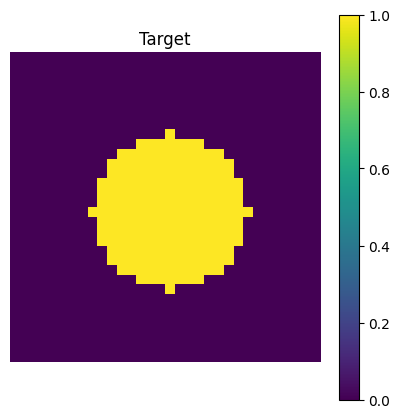

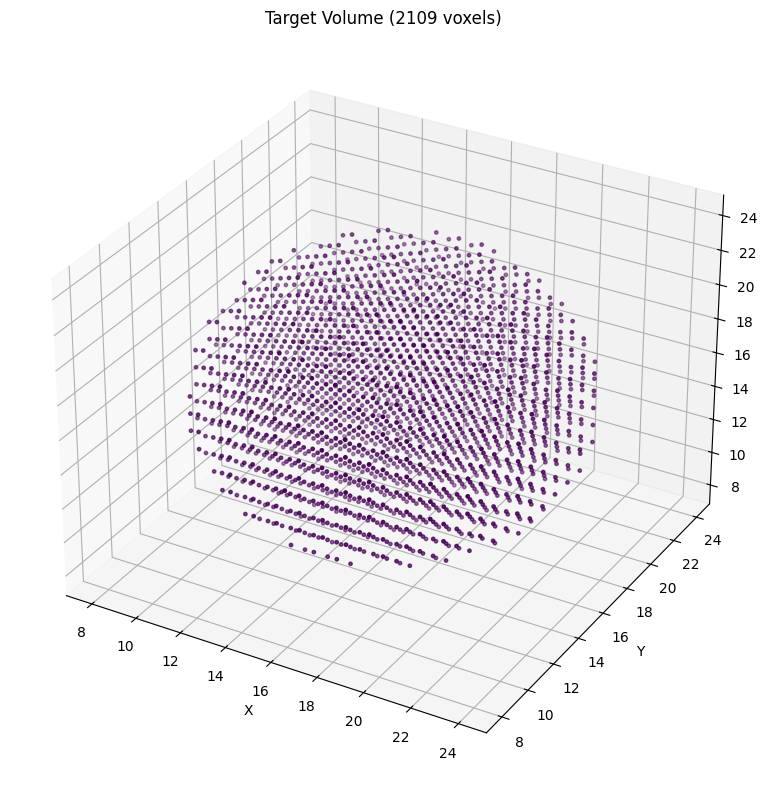

2109

In [3]:
D, H, W = grid_cfg.size
radius = min(grid_cfg.size) / 4.0
cz, cy, cx = D / 2.0, H / 2.0, W / 2.0
zz = torch.arange(0, D, device=device).view(D, 1, 1).expand(D, H, W).float()
yy = torch.arange(0, H, device=device).view(1, H, 1).expand(D, H, W).float()
xx = torch.arange(0, W, device=device).view(1, 1, W).expand(D, H, W).float()
dist = torch.sqrt((zz - cz) ** 2 + (yy - cy) ** 2 + (xx - cx) ** 2)
occ = (dist <= radius).float()
target = occ.unsqueeze(0).unsqueeze(0)

viz.show_slice_target(target)
viz.show_volume_target_mpl(target)

In [4]:
print("stability run:")
state = model.seed_center(batch_size=1, device=device)
state += 1e-3 * torch.randn_like(state)
with torch.no_grad():
    for i in range(8):
        state = model(state, steps=1)
        print(f"step {i:02d} mean={state.mean().item():+.6f} std={state.std().item():.6f}")

stability run:
step 00 mean=+0.000003 std=0.001838
step 01 mean=+0.000003 std=0.001838
step 02 mean=+0.000003 std=0.001838
step 03 mean=+0.000003 std=0.001838
step 04 mean=+0.000003 std=0.001838
step 05 mean=+0.000003 std=0.001838
step 06 mean=+0.000003 std=0.001838
step 07 mean=+0.000003 std=0.001838



starting multi-step training
Iter 00001, Loss=0.515620, Mean Alpha=0.0003


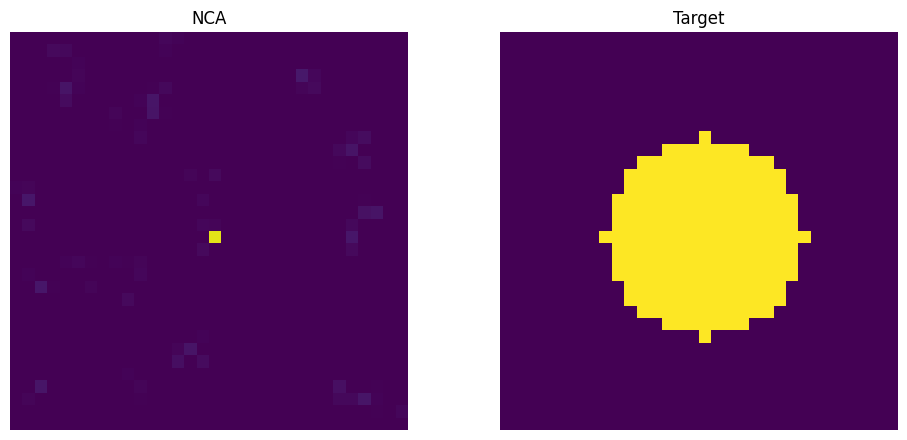

Iter 00200, Loss=0.440052, Mean Alpha=0.0663


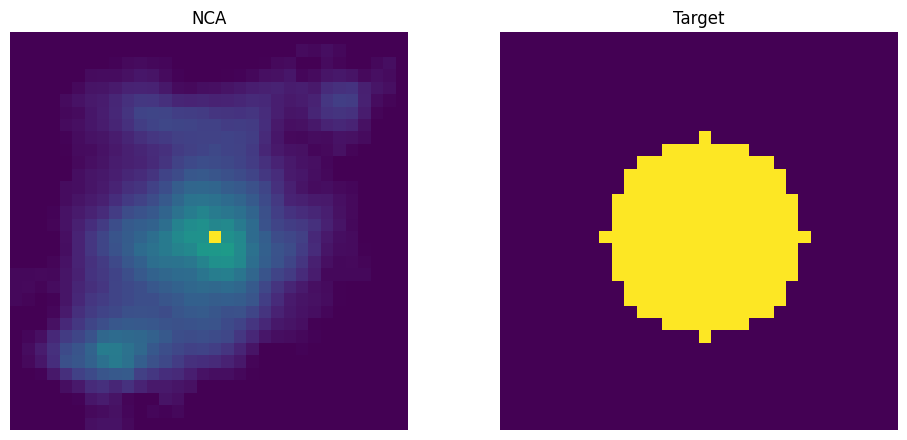

Iter 00400, Loss=0.371542, Mean Alpha=0.0401


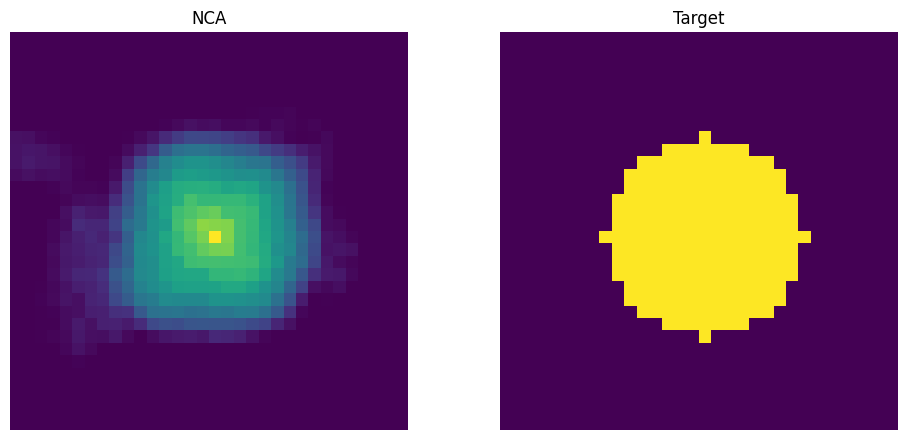

Iter 00600, Loss=0.372077, Mean Alpha=0.0343


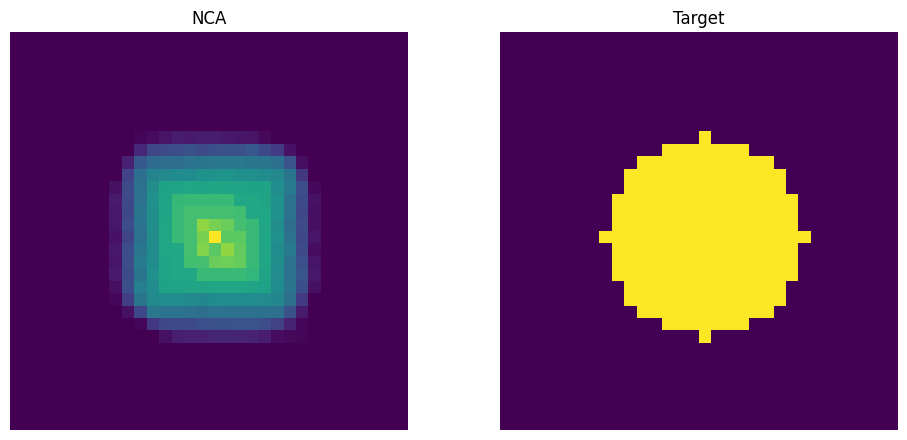

Iter 00800, Loss=0.375023, Mean Alpha=0.0332


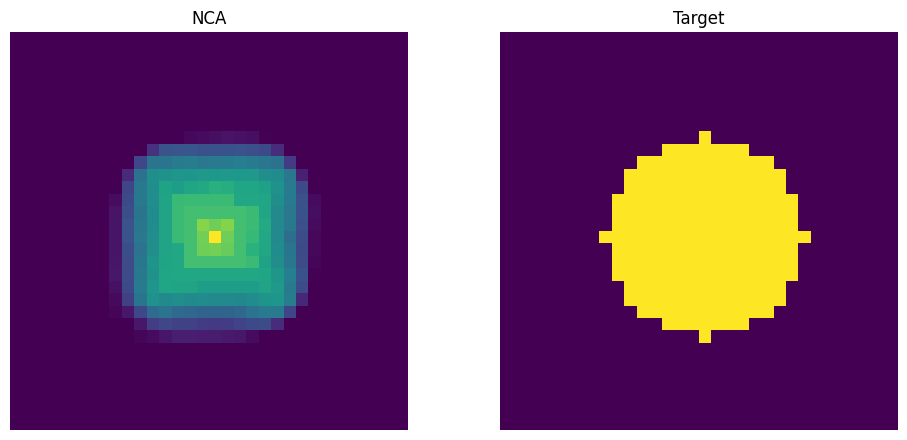

Iter 01000, Loss=0.369915, Mean Alpha=0.0359


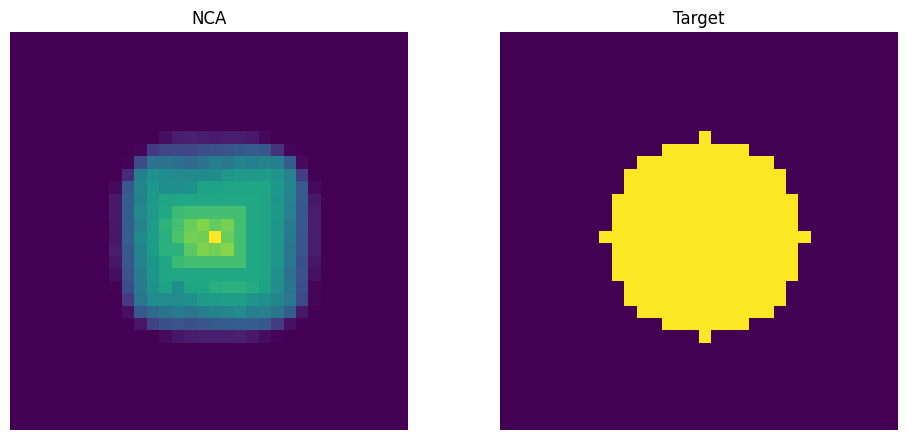

Iter 01200, Loss=0.374544, Mean Alpha=0.0318


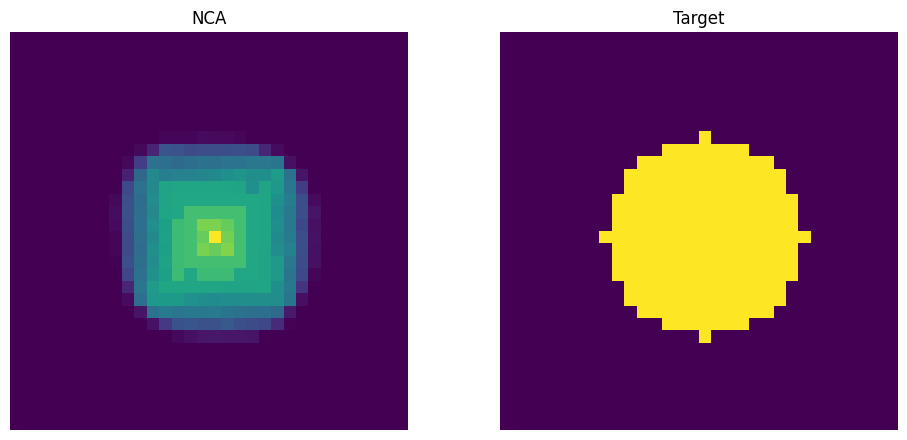

Iter 01400, Loss=0.371253, Mean Alpha=0.0339


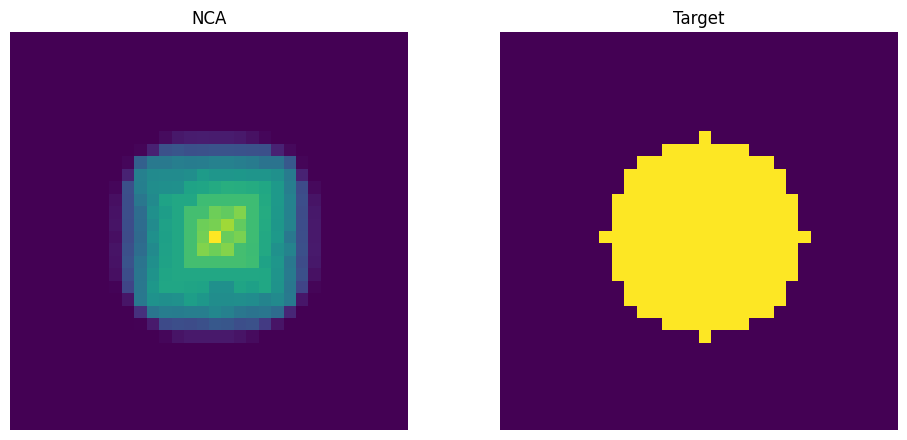

Iter 01600, Loss=0.364606, Mean Alpha=0.0313


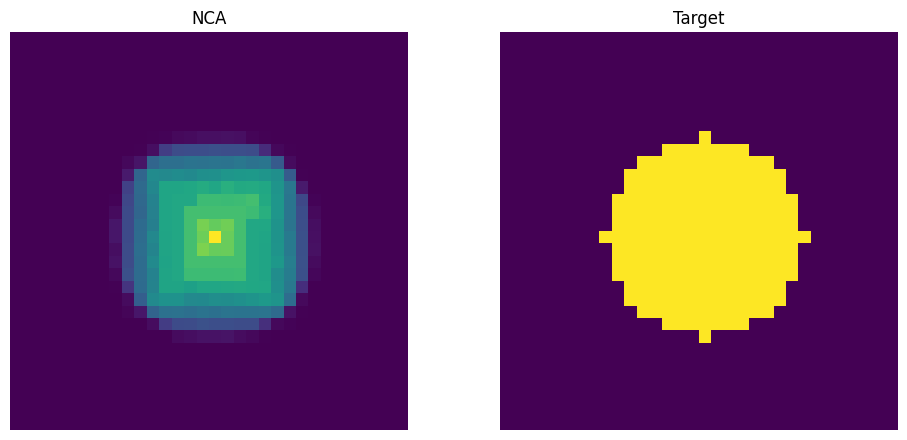

Iter 01800, Loss=0.359478, Mean Alpha=0.0329


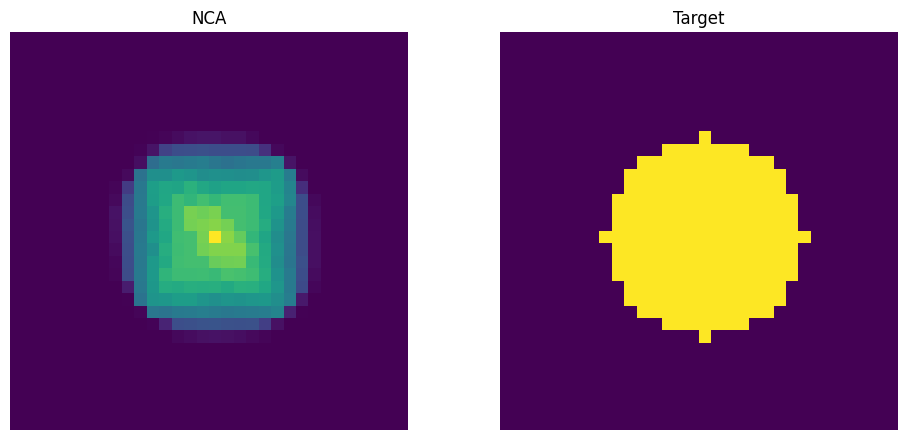

Iter 02000, Loss=0.359770, Mean Alpha=0.0345


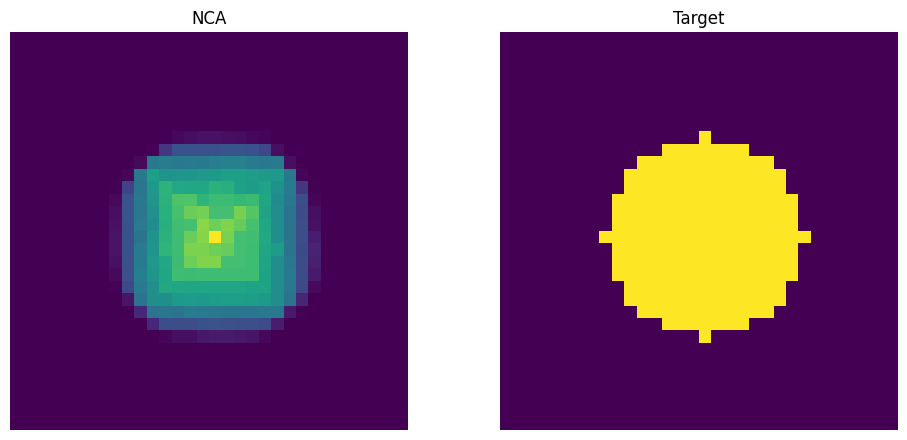

training took 65.90471887588501 s


In [5]:
print("\nstarting multi-step training")
optim = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
losses = []
iters = 2000
n_steps = 8
log_interval = 200

start = time.time()
for it in range(1, iters+1):
    state = model.seed_center(batch_size=1, device=device)
    state += 0.02 * torch.randn_like(state)
    optim.zero_grad()
    loss = 0.0
    for step in range(n_steps):
        state = model(state, steps=1)
        alpha = state[:, -1:, ...]
        loss += F.mse_loss(alpha, target)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optim.step()
    losses.append(loss.item())
    if it % log_interval == 0 or it==1:
        print(f"Iter {it:05d}, Loss={loss.item():.6f}, Mean Alpha={alpha.mean().item():.4f}")
        viz.show_slice_comparison(state, target, idx=16)
    if loss.item() < 0.35:
        print("Best result")
        print(f"Iter {it:05d}, Loss={loss.item():.6f}, Mean Alpha={alpha.mean().item():.4f}")
        viz.show_slice_comparison(state, target, idx=16)
        break
print("training took", time.time() - start, "s")

final alive voxels: 2105


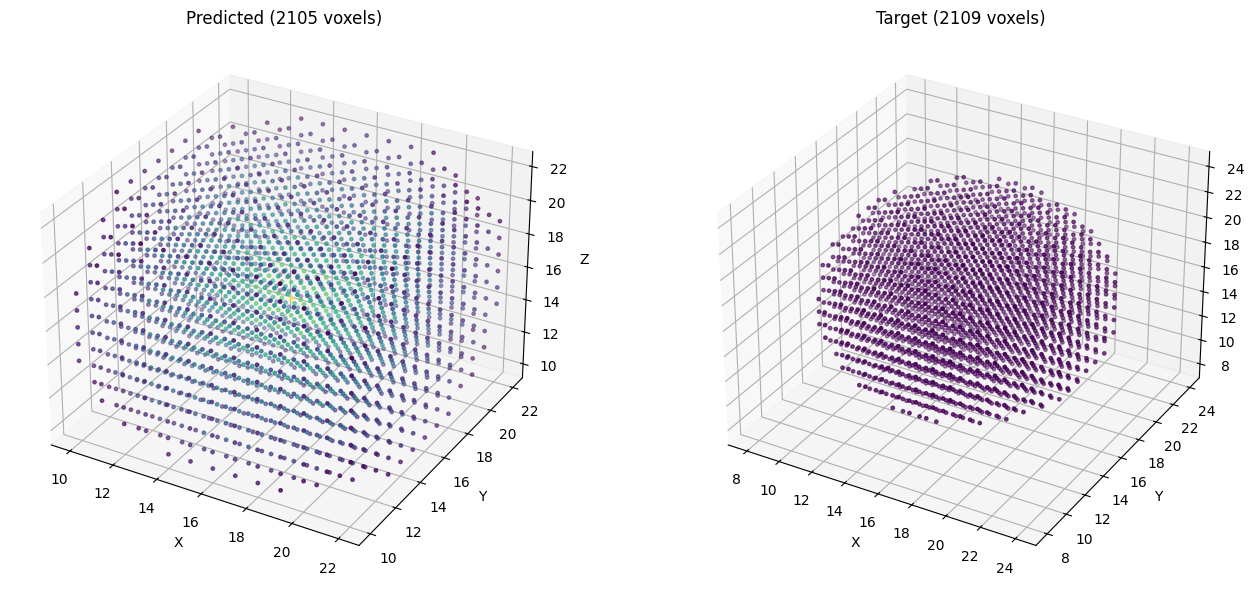

(2105, 2109)

In [6]:
with torch.no_grad():
    state = model.seed_center(batch_size=1, device=device)
    state += 1e-3 * torch.randn_like(state)
    state = model(state, steps=8)
    alpha = state[:, -1:, ...].cpu().numpy().squeeze()

thresh = 0.2
xs, ys, zs = np.nonzero(alpha > thresh)
print("final alive voxels:", len(xs))
viz.show_volume_comparison_mpl(state, target)

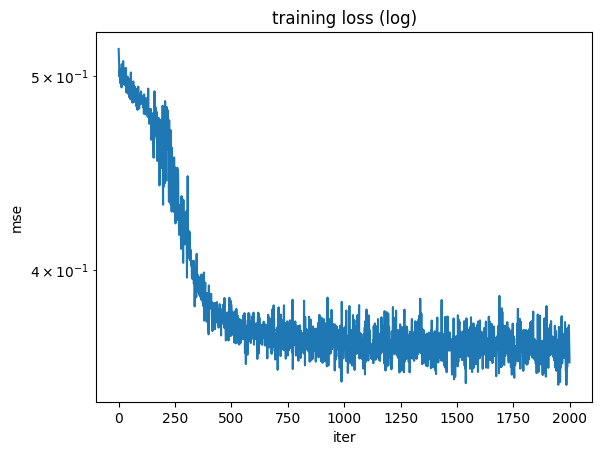

In [7]:
plt.figure()
plt.plot(losses)
plt.yscale("log")
plt.title("training loss (log)")
plt.xlabel("iter")
plt.ylabel("mse")
plt.show()